# Deconvolution 0.1

## Introduction

Here the deconvolution of ST lung samples using the snRNA-seq data is performed.

In [1]:
setwd("/scratch_isilon/groups/singlecell/shared/projects/covid-pascual-reguant")

## Libraries

In [2]:
library(here)
library(glue)
library(tidyverse)
library(BiocParallel)
library(Seurat)
library(SingleCellExperiment)
library(SpatialExperiment)
library(HDF5Array)
library(scater)
library(scran)
library(SPOTlight)

here() starts at /scratch_isilon/groups/singlecell/shared/projects/covid-pascual-reguant

── Attaching core tidyverse packages ───────────────────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ─────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t


Loading required package: SummarizedExperiment

Loading required package: M

## Load data

In [3]:
se <- "~/SP-COVID/snRNAseq/0-annotation/out/se_annot_filtered.rds" %>%
    readRDS(.)
sce <- as.SingleCellExperiment(se)
sce

spe <- loadHDF5SummarizedExperiment(dir = "~/SP-COVID/visium/0-processing/out/3-annot_lung_spe")
spe

class: SingleCellExperiment 
dim: 38720 31757 
metadata(0):
assays(2): counts logcounts
rownames(38720): WASH7P AL627309.1 ... RAB9AP5 MT-TR
rowData names(0):
colnames(31757): O325-akut_GGTTGTAGTACTTCCC-1
  O325-akut_GAAGGACAGAGCCATG-1 ... T188-R2-prolonged_GGAGGATCAGTCTACA-1
  T188-R2-prolonged_TCATGGAAGGGATCAC-1
colData names(71): orig.ident nCount_RNA ... annotation ident
reducedDimNames(3): PCA HARMONY UMAP
mainExpName: RNA
altExpNames(1): integrated

class: SpatialExperiment 
dim: 30450 33211 
metadata(0):
assays(2): counts logcounts
rownames(30450): ENSG00000238009 ENSG00000241860 ... SCoV2_ORF10
  SCoV2_UTR3
rowData names(5): symbol subsets_mito subsets_ribo subsets_SCoV2
  gene_name
colnames(33211): AAACAAGTATCTCCCA-1 AAACACCAATAACTGC-1 ...
  TTGTTTCCATACAACT-1 TTGTTTGTGTAAATTC-1
colData names(39): in_tissue array_row ... lisi_study_id annotation
reducedDimNames(3): PCA UMAP HARMONY
mainExpName: NULL
altExpNames(0):
spatialCoords names(2) : pxl_col_in_fullres pxl_row_in_fullres
imgData names(4): sample_id image_id data scaleFactor

In [4]:
colnames(spe) <- paste(colData(spe)$cond_tissue, colnames(spe), sep = "_")
rowData(spe)$ensembl <- rownames(spe)
rownames(spe) <- rowData(spe)$gene_name

## Preprocessing

If the dataset is very large we want to downsample it to train the model, both in of number of cells and number of genes. To do this, we want to keep a representative amount of cells per cluster and the most biologically relevant genes.

In the paper we show how downsampling the **number of cells per cell identity to ~100** doesn’t affect the performance of the model. Including >100 cells per cell identity provides marginal improvement while greatly increasing computational time and resources. Furthermore, restricting the gene set to the **marker genes for each cell type along with up to 3.000 highly variable genes** further optimizes performance and computational resources. You can find a more detailed explanation in the original paper.

### Feature selection

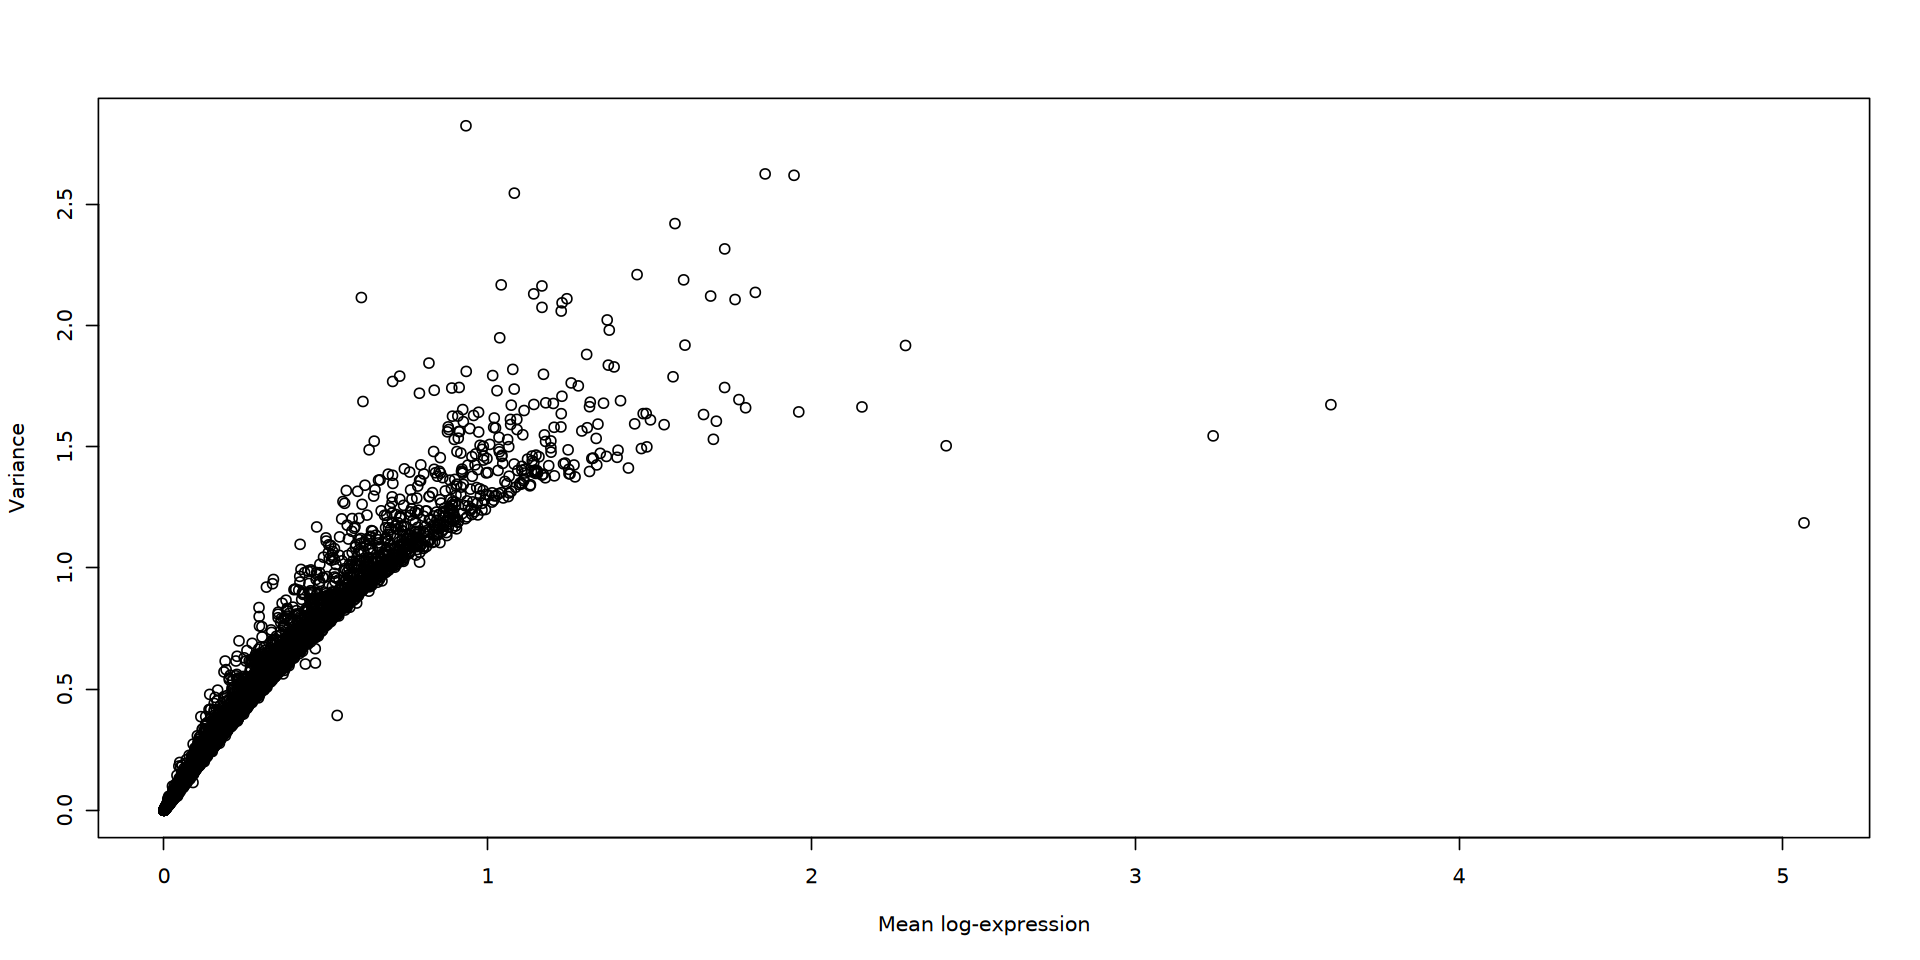

In [5]:
options(repr.plot.width = 16, repr.plot.height = 8, warn = -1)

genes <- !grepl(pattern = "^RP[LS]|^MT-|^MTRNR|^SCoV2", x = rownames(sce)) 

dec <- modelGeneVar(sce, subset.row = genes, block = sce$orig.ident)
plot(dec$mean, dec$total, xlab = "Mean log-expression", ylab = "Variance")

In [6]:
hvg <- getTopHVGs(dec, n = 3000)

In [7]:
colLabels(sce) <- colData(sce)$annotation
mgs <- scoreMarkers(sce, subset.row = genes)

We will keep marker genes with AUC > 0.8.

In [8]:
options(max.print = 99999)
mgs_fil <- lapply(names(mgs), function(i) {
    x <- mgs[[i]]
    threshold <- 0.8 
    x <- x[x$mean.AUC > threshold, ]
    if (nrow(x) == 0) return(NULL)
    x <- x[order(x$mean.AUC, decreasing = TRUE), ]
    x$gene <- rownames(x)
    x$cluster <- i
    data.frame(x)
})

mgs_df <- do.call(rbind, mgs_fil)
print(mgs_df[, c("gene", "mean.AUC", "cluster")])

                  gene  mean.AUC                       cluster
COL1A2          COL1A2 0.8896692                          AdvF
LAMA2            LAMA2 0.8866838                          AdvF
COL6A3          COL6A3 0.8818563                          AdvF
COL3A1          COL3A1 0.8400638                          AdvF
COL1A1          COL1A1 0.8245086                          AdvF
BICC1            BICC1 0.8175014                          AdvF
DCN                DCN 0.8163023                          AdvF
CACNA1C        CACNA1C 0.8074001                          AdvF
CACNB2          CACNB2 0.8044025                          AdvF
COL6A2          COL6A2 0.8043165                          AdvF
ADGRL2          ADGRL2 0.9663491                     Aerocytes
GALNT18        GALNT18 0.9414012                     Aerocytes
AFF3              AFF3 0.8761456                     Aerocytes
PRKCE            PRKCE 0.8284066                     Aerocytes
THSD4            THSD4 0.8278487                     Ae

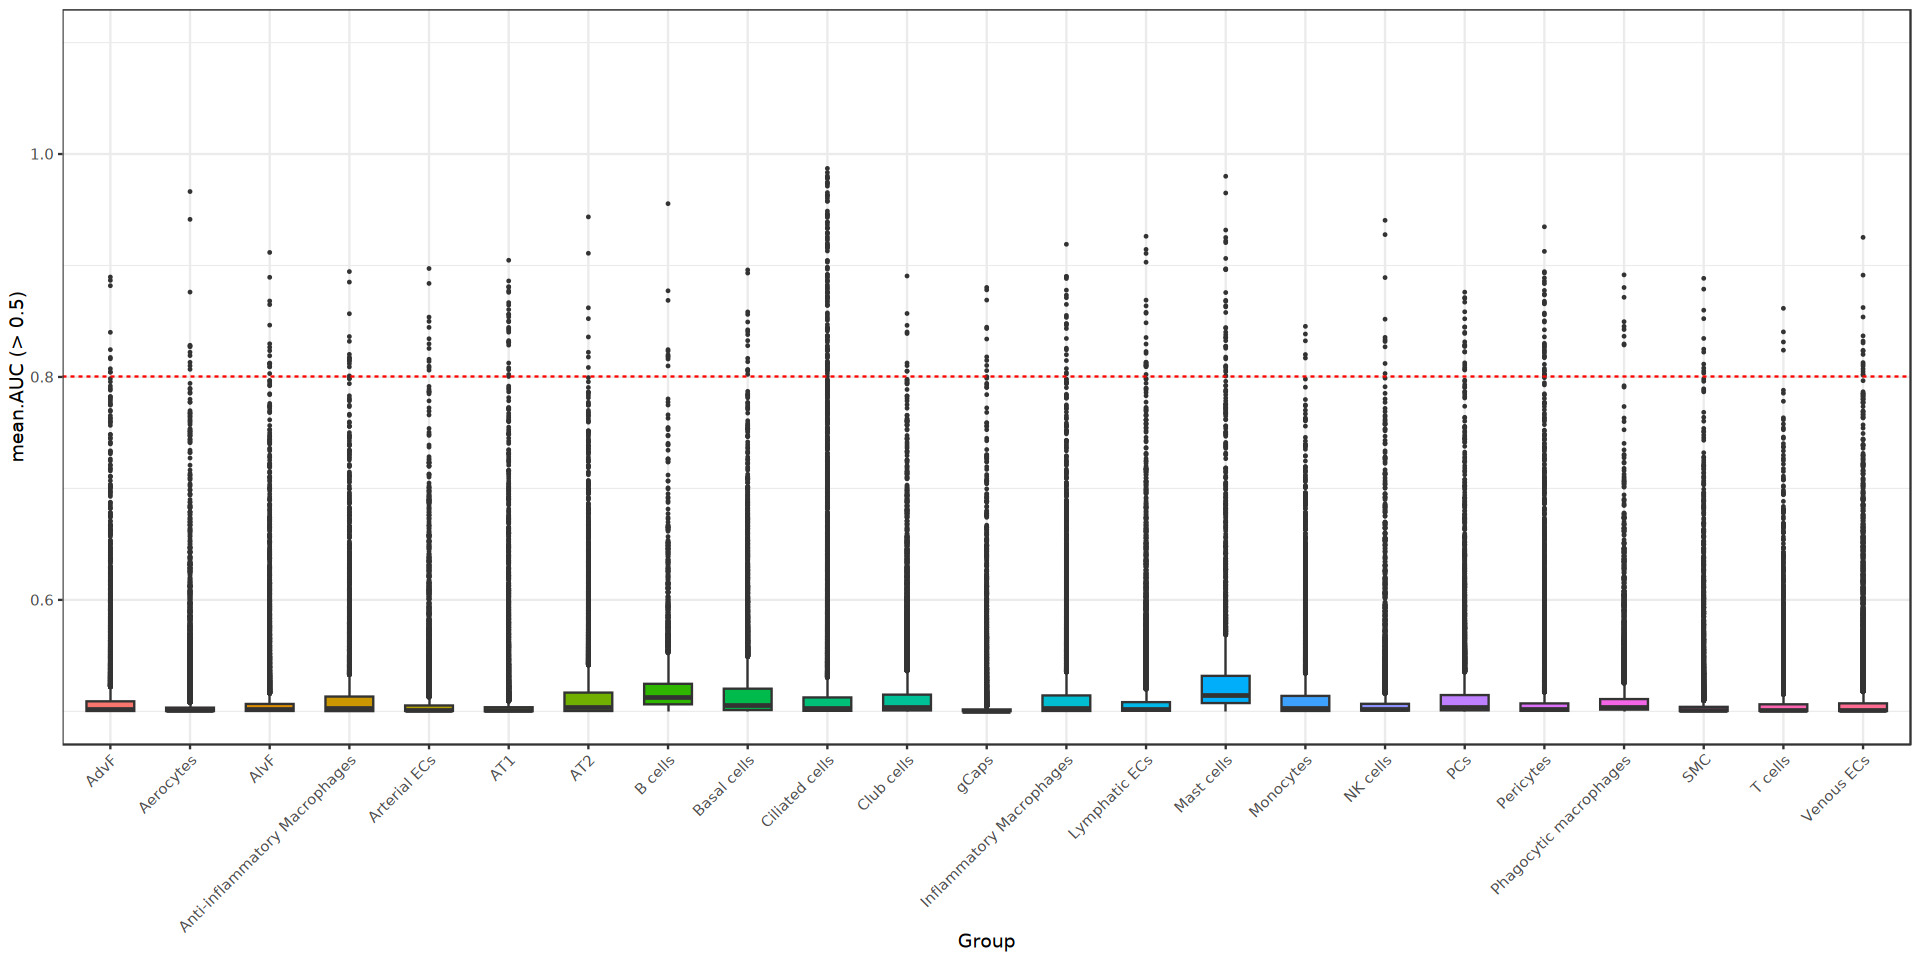

In [9]:
lapply(names(mgs), function(grp) {
    data.frame(mean.AUC = mgs[[grp]]$mean.AUC,
               group = grp)
}) %>% 
do.call(rbind, .) %>%
filter(mean.AUC > 0.5) %>%
 
    ggplot(aes(x = group, y = mean.AUC, fill = group)) +
    geom_boxplot(width = 0.6, outlier.size = 0.3) +
    geom_hline(yintercept = 0.8, linetype = "dashed", color = "red") +
    scale_x_discrete(limits = names(mgs)) +
    scale_y_continuous(limits = c(0.5, 1.1)) +
    theme_bw() +
    theme(axis.text.x = element_text(angle = 45, hjust = 1),
          legend.position = "none") +
    labs(x = "Group", y = "mean.AUC (> 0.5)")

In [10]:
known_markers <- list(
    `Mast cells` = c("TPSAB1", "TPSB2", "CPA3", "KIT", "FCER1A"),
    `PCs` = c("JCHAIN", "IGHA1", "IGHG3", "XBP1", "MZB1"),
    `B cells` = c("MS4A1", "CD19", "CD79A", "CD79B", "CD74"),
    `NK cells` = c("NCAM1", "KLRC1", "KLRF1", "GNLY", "NKG7"),
    `T cells` = c("CD3D", "CD3E", "TRAC", "IL7R", "SKAP1", "ARHGAP15"),
    `Monocytes` = c("FCGR3A", "S100A8", "S100A9", "MNDA", "VCAN"),
    `Phagocytic macrophages` = c("C1QA", "C1QB", "MRC1", "CD163", "LYZ"),
    `Inflammatory Macrophages` = c("CXCL10", "PPARG", "TFRC", "IL1B", "TNF"),
    `Anti-inflammatory Macrophages` = c("MRC1", "CD163", "FMN1", "CTSB", "ARG1"),
    `AdvF` = c("COL1A2", "LAMA2", "COL6A3", "COL3A1", "DCN"),
    `AlvF` = c("A2M", "COL1A2", "COL6A3", "FN1", "DCN"),
    `Pericytes` = c("PDGFRB", "RGS5", "ACTA2", "NOTCH3", "CSPG4"),
    `SMC` = c("MYH11", "ACTA2", "TAGLN", "CNN1", "CALD1"),
    `Lymphatic ECs` = c("PROX1", "LYVE1", "PDPN", "FLT4", "CCL21"),
    `Venous ECs` = c("VWF", "NR2F2", "ACKR1", "EPAS1", "PECAM1"),
    `Arterial ECs` = c("HEY1", "GJA5", "EFNB2", "BMX", "AXL"),
    `gCaps` = c("PLVAP", "PLXDC2", "ADGRL4", "ICAM2", "TM4SF1"),
    `Aerocytes` = c("ADGRL2", "GALNT18", "EPAS1", "PRKG1", "PDE4DIP"),
    `Basal cells` = c("TP63", "KRT5", "KRT17", "EGFR", "ITGA6"),
    `Club cells` = c("SCGB1A1", "SCGB3A2", "CYP2F2", "FOXA3", "GRPR"),
    `Ciliated cells` = c("FOXJ1", "DNAH5", "CFAP65", "DYNC2H1", "HEPACAM"),
    `AT2` = c("SFTPB", "SFTPC", "SFTPD", "ABCA3", "ETV5"),
    `AT1` = c("AQP5", "PDPN", "AGER", "ATP6V0A4", "RTKN2")
)

man_mgs <- imap_dfr(known_markers, function(gene_vec, cl){
  x <- mgs[[cl]]
  if (is.null(x)) return(NULL)

  g_keep <- intersect(gene_vec, rownames(x))
  if (length(g_keep) == 0) return(NULL)

  x_sub <- x[g_keep, , drop = FALSE]
  x_sub$gene <- rownames(x_sub)
  x_sub$cluster <- cl
  as.data.frame(x_sub)
})

mgs_df_all <- bind_rows(mgs_df, man_mgs) %>%
  arrange(cluster, desc(mean.AUC)) %>%
  distinct(cluster, gene, .keep_all = TRUE)

### Cell downsampling

In [11]:
score_cells_by_markers <- function(sce, mgs_df, annotation_col = "annotation") {
  expr <- logcounts(sce)
  clusters <- unique(sce[[annotation_col]])
  scores <- rep(0, ncol(sce))
  names(scores) <- colnames(sce)
  
  for (cl in clusters) {
    markers <- mgs_df %>%
      filter(cluster == cl) %>%
      pull(gene)
    markers <- intersect(markers, rownames(sce))
    
    if (length(markers) == 0) next
    cell_idx <- which(sce[[annotation_col]] == cl)
    weights <- mgs_df %>%
      filter(cluster == cl, gene %in% markers) %>%
      arrange(match(gene, markers)) %>%
      pull(mean.AUC)
    
    marker_expr <- expr[markers, cell_idx, drop = FALSE]
    scores[cell_idx] <- as.numeric(weights %*% marker_expr) / sum(weights)
  }
  
  return(scores)
}

cell_scores <- score_cells_by_markers(sce, mgs_df_all)
sce$marker_score <- cell_scores

n_cells <- 100
idx <- split(seq(ncol(sce)), sce$annotation)

cs_keep <- lapply(idx, function(i) {
  n <- min(length(i), n_cells)
  i[order(cell_scores[i], decreasing = TRUE)[1:n]]
})

sce_down <- sce[, unlist(cs_keep)]

bind_cols(
  as.data.frame(table(sce$annotation)),
  as.data.frame(table(sce_down$annotation)) %>% select(Freq)
) %>%
  setNames(c("cluster", "before", "after")) %>%
  knitr::kable()

New names:
• `Freq` -> `Freq...2`
• `Freq` -> `Freq...3`




|cluster                       | before| after|
|:-----------------------------|------:|-----:|
|AdvF                          |   1616|   100|
|Aerocytes                     |   1560|   100|
|AlvF                          |   1277|   100|
|Anti-inflammatory Macrophages |   4061|   100|
|Arterial ECs                  |    950|   100|
|AT1                           |   3824|   100|
|AT2                           |   2772|   100|
|B cells                       |     36|    36|
|Basal cells                   |    472|   100|
|Ciliated cells                |   1199|   100|
|Club cells                    |    626|   100|
|gCaps                         |   4049|   100|
|Inflammatory Macrophages      |   1396|   100|
|Lymphatic ECs                 |    797|   100|
|Mast cells                    |     29|    29|
|Monocytes                     |   1331|   100|
|NK cells                      |    503|   100|
|PCs                           |    504|   100|
|Pericytes                     |    83

## Deconvolution

In [12]:
res <- SPOTlight(x = sce_down, y = spe,
                 groups = as.character(sce_down$annotation),
                 mgs = mgs_df_all, hvg = hvg,
                 weight_id = "mean.AUC",
                 group_id = "cluster",
                 gene_id = "gene")

Scaling count matrix

Seeding NMF model...

Training NMF model...




iter |      tol 
---------------
   1 | 5.43e-01
   2 | 2.06e-02
   3 | 5.50e-03
   4 | 2.81e-03
   5 | 3.70e-03
   6 | 6.61e-03
   7 | 4.40e-03
   8 | 1.00e-03
   9 | 2.67e-04
  10 | 9.20e-05
  11 | 4.04e-05
  12 | 2.20e-05
  13 | 1.37e-05
  14 | 9.16e-06


Time for training: 0.01min

Removing genes in mixture matrix that are all 0s

Keep intersection of genes between W and mixture matrix

Deconvoluting mixture data...



## Save data

In [13]:
out_dir <- "~/SP-COVID/visium/1-deconvolution/out"

"{out_dir}/deconvolution_results_lung.rds" %>%
    glue::glue() %>%
  saveRDS(object = res, file = .)

"{out_dir}/sce_downsampled_lung.rds" %>%
    glue::glue() %>%
  saveRDS(object = sce_down, file = .)

# Session information

In [14]:
sessionInfo()

R version 4.5.2 (2025-10-31)
Platform: x86_64-conda-linux-gnu
Running under: CentOS Linux 7 (Core)

Matrix products: default
BLAS/LAPACK: /home/groups/singlecell/cvicente/miniconda3/envs/COVID/lib/libopenblasp-r0.3.30.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

time zone: Europe/Madrid
tzcode source: system (glibc)

attached base packages:
[1] stats4    stats     graphics  grDevices utils     datasets  methods  
[8] base     

other attached packages:
 [1] SPOTlight_1.14.0            scran_1.38.0               
 [3] scater_1.38.0               scuttle_1.20.0             
 [5] HDF5Array_1.38.0            h5mread_1.2.1              
 [7] rhdf5_2.5